In this notebook we will look at a kidney disease dataset with a wide range of markers. We will demonstrate the use of dimensionality reduction, and then subsequently feeding the reduced dimension dataset into a basic classification model. PCA will be used for dimensionality reduction and we will use logistic regression for out classification. 

This notebook mainly focuses on the application of the PCA process for dimensionality reduction. The addition of classification analysis is more to show how post PCA data can be fed into further processes.

In [1]:
# Packages installation
%pip install pandas numpy matplotlib seaborn scikit-learn
print("✅ Packages installed successfully.")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully.


In [2]:
import pandas as pd
import numpy as np

# 3.7.1 for Kaggle compatibility
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("✅ Dependencies loaded successfully.")

✅ Dependencies loaded successfully.


In [3]:
df = pd.read_csv("data/kidney_disease.csv")
print("✅ Dataset read successfully.")

✅ Dataset read successfully.


## Exploratory Data Analysis

In [4]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


| Variable Name | Description            |
|---------------|------------------------|
| age           |                        |
| bp            | blood pressure         |
| sg            | specific gravity       |
| al            | albumin                |
| su            | sugar                  |
| rbc           | red blood cells        |
| pc            | pus cell               |
| pcc           | pus cell clumps        |
| ba            | bacteria               |
| bgr           | blood glucose random   |
| bu            | blood urea             |
| sc            | serum creatinine       |
| sod           | sodium                 |
| pot           | potassium              |
| hemo          | hemoglobin             |
| pcv           | packed cell volume     |
| wbcc          | white blood cell count |
| rbcc          | red blood cell count   |
| htn           | hypertension           |
| dm            | diabetes mellitus      |
| cad           | coronary artery disease|
| appet         | appetite               |
| pe            | pedal edema            |
| ane           | anemia                 |
| class         | ckd or not ckd         |


We will rename the dataframe columns with reference to the above key in order to improve readability.

In [5]:
df.drop('id', axis = 1, inplace = True)
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'anemia', 'class']


Looking at the dataframe info, we can see a wide range of variables with different types. Furthermore there are many null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
blood_pressure,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
specific_gravity,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
albumin,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
sugar,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
blood_glucose_random,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
blood_urea,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
serum_creatinine,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sodium,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
potassium,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


We will start with an analysis of the categorical variables to see how they are distributed.

C:\Users\RickReyJim\AppData\Local\Temp\ipykernel_20324\3991186973.py:25: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
c:\GIT\CDK\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\GIT\CDK\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


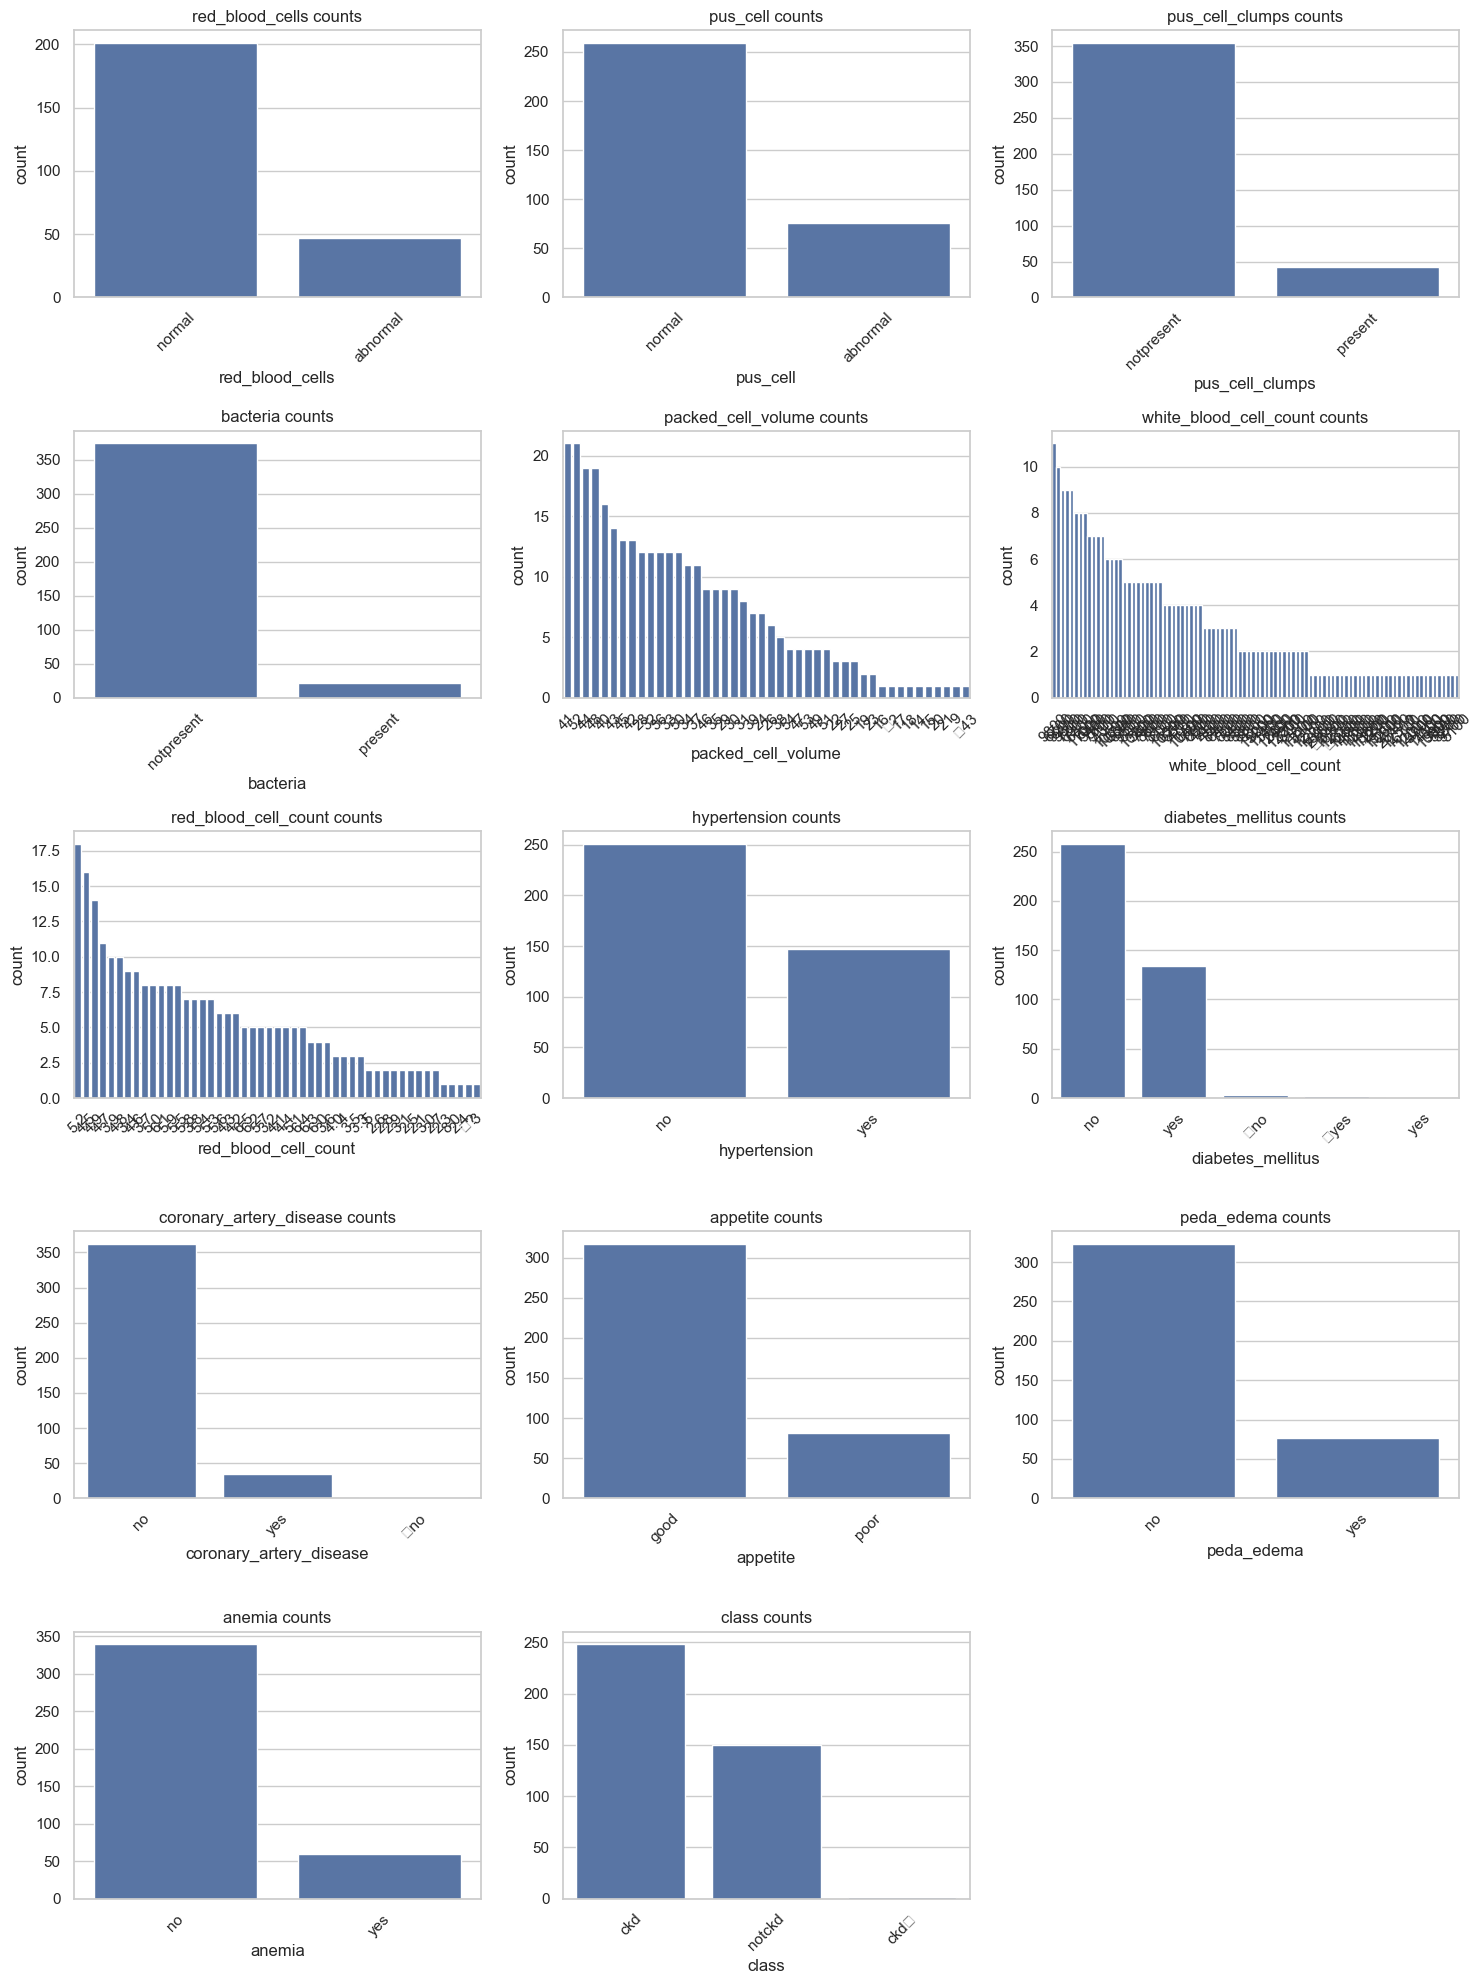

In [8]:
# Automatically detect categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [col for col in cat_cols]

# Set plotting style
sns.set(style="whitegrid")

# Determine grid size
n_cols = 3  # number of columns in the grid
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # automatically calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()  # flatten in case of multiple rows

# Plot each categorical column
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'{col} counts')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From this we can see, unclean data regarding:
- variation in vaiable names - "no", "yes", " no" etc
- numeric variables seemly displayed as a object

As fixing this does not cause data leakage we can do it before the train test split.

We can also take note of the balance in the "class" categorical variable. This is our target variable and shows whether a person has kidney disease or not, as it is not 50/50 we will need to take this balance into account.

In [9]:
# fixing misspelled values

mapping = {
    "yes": "yes", 
    " yes": "yes", 
    "\tyes": "yes",
    "no": "no", 
    "\tno": "no"
}

df["diabetes_mellitus"] = df["diabetes_mellitus"].map(mapping).fillna(np.nan)
df["coronary_artery_disease"] = df["coronary_artery_disease"].map(mapping).fillna(np.nan)

mapping = {
    "ckd": "ckd", 
    "ckd\t": "ckd",
    "notckd": "notckd"
}

df["class"] = df["class"].map(mapping).fillna(np.nan)

In [10]:
# Convert object columns that are actually numeric
num_like_cols = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']

for col in num_like_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Inspecting the numeric variables to see how they are distributed.

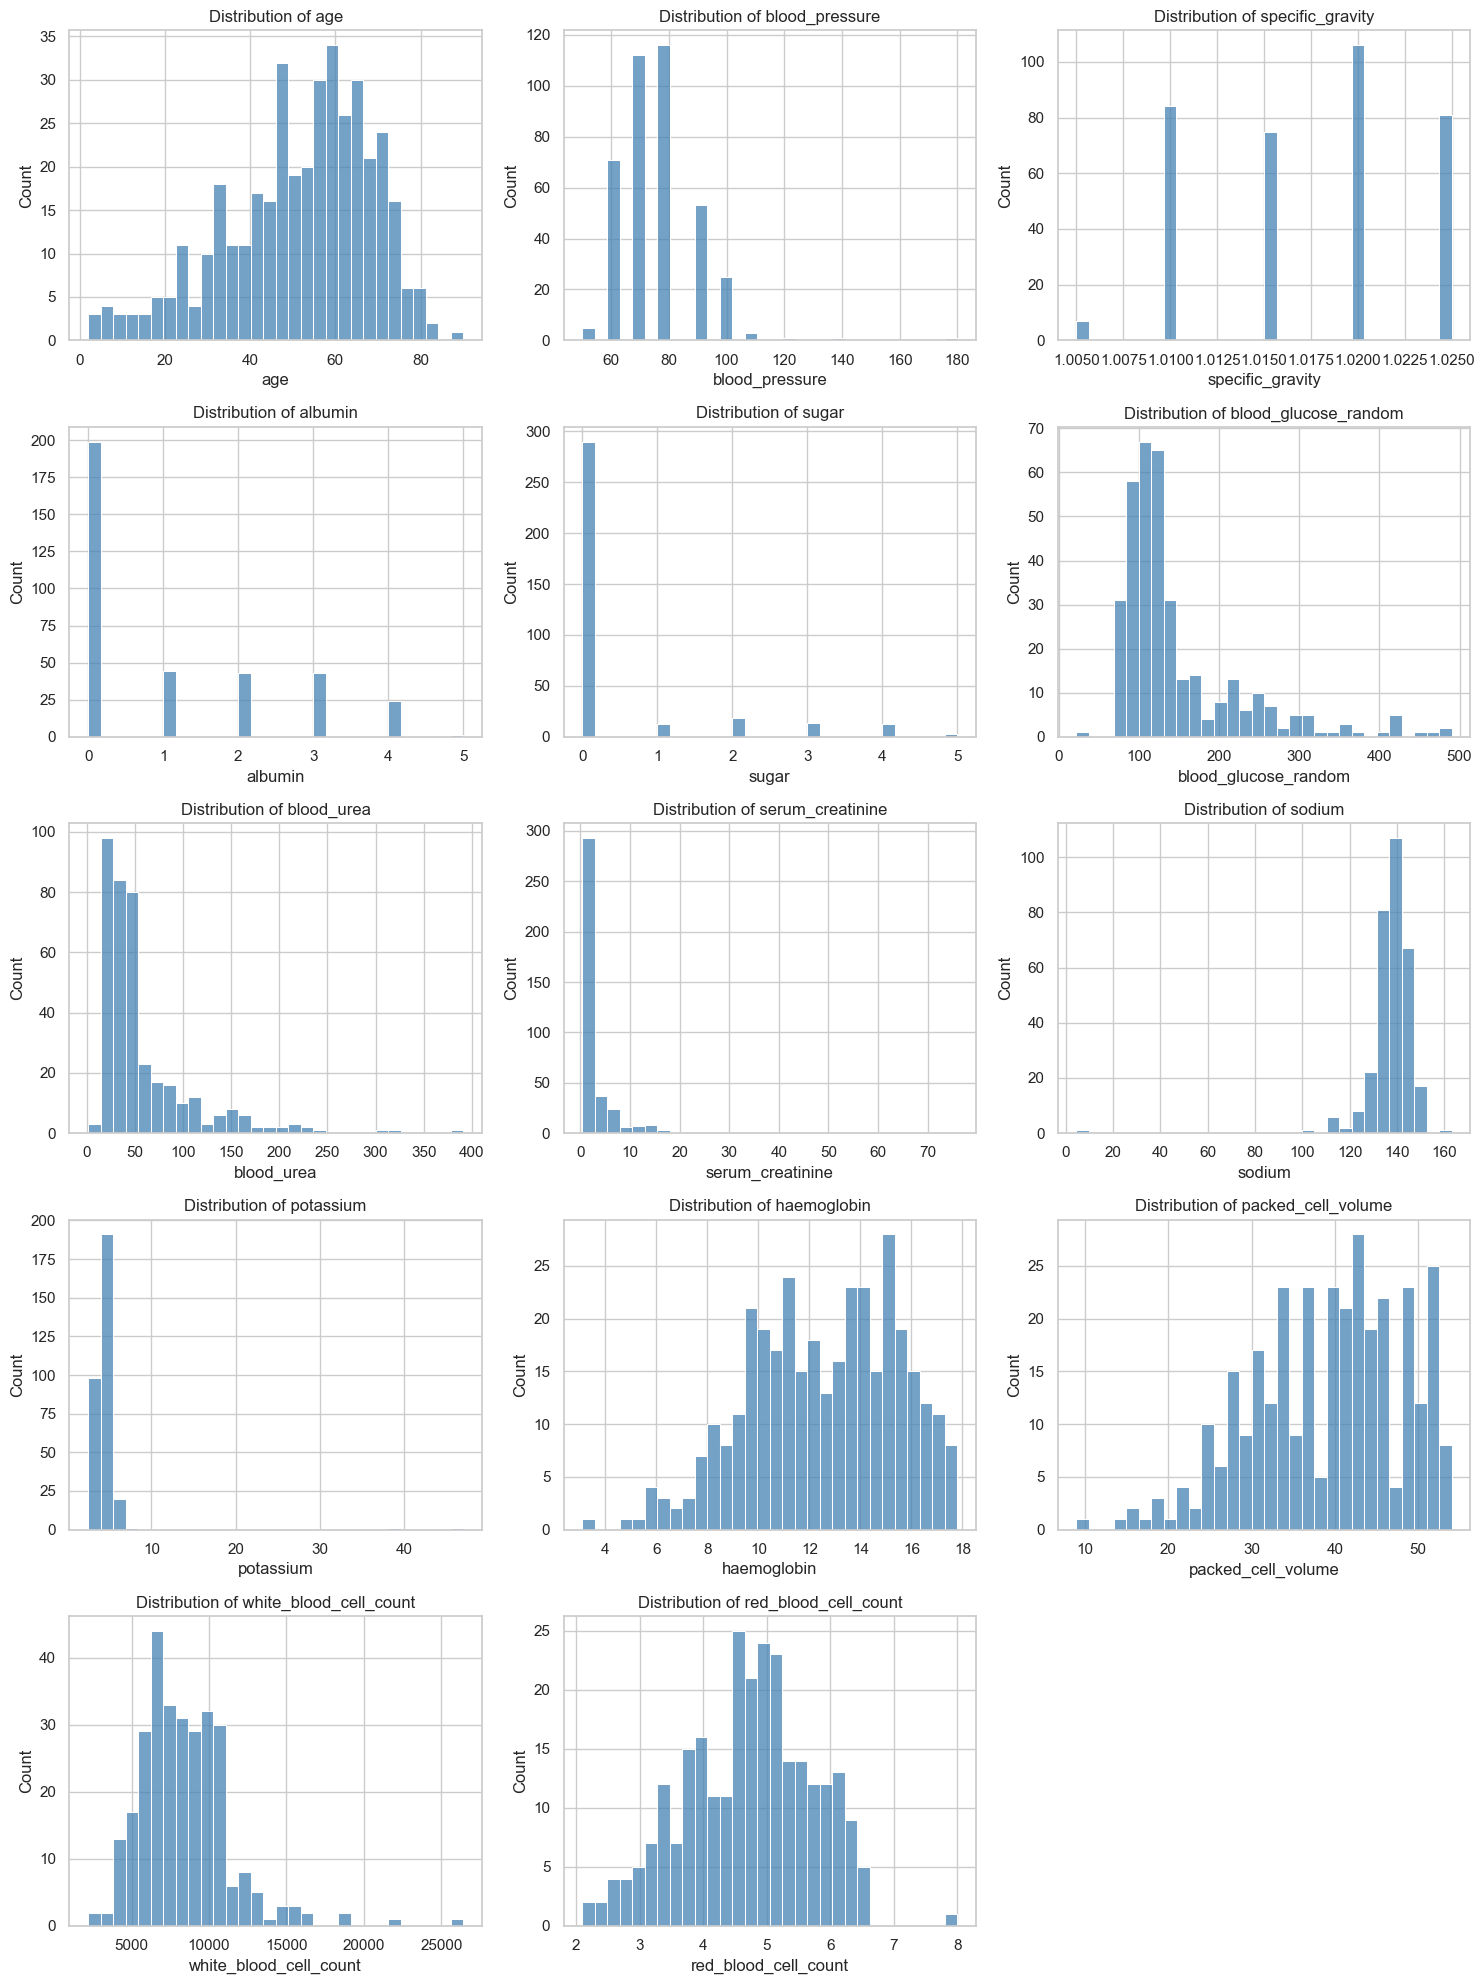

In [11]:
# Select only numeric columns (int64 or float64)
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Plot style
sns.set(style="whitegrid")

# Determine grid size
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

# Plot each numeric feature
for i, col in enumerate(num_features):
    sns.histplot(df[col].dropna(), bins=30, kde=False, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
(df[num_features] < 0).sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

We dont see any negative values. But there are some potential issues with outlier on blood pressure, serum_creatine and potassium. Without domain specific knowledge I will not be adjusting them as they could be valid values.

## Pre-split prep for categorical data

In order to perform the dimensionality reduction method PCA, all values need to be in numeric form. Looking the unique value for each categorical variable below, we can see that they are infact binary with the addition of a nan value. We can keep the nan for now (sorting it out later post split to avoid data leakage), and assign the categoric variables to a 0 or a 1.

In [13]:
# Select object columns
obj_cols = df.select_dtypes(include='object').columns

# Print unique values for each object column
for col in obj_cols:
    print(f"{col}: {df[col].unique()}")

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumps: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' nan]
coronary_artery_disease: ['no' 'yes' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
anemia: ['no' 'yes' nan]
class: ['ckd' 'notckd']


In [14]:
# Mapping dictionary for each column
bool_mappings = {
    'red_blood_cells': {'normal': 1, 'abnormal': 0},
    'pus_cell': {'normal': 1, 'abnormal': 0},
    'pus_cell_clumps': {'present': 1, 'notpresent': 0},
    'bacteria': {'present': 1, 'notpresent': 0},
    'hypertension': {'yes': 1, 'no': 0},
    'diabetes_mellitus': {'yes': 1, 'no': 0},
    'coronary_artery_disease': {'yes': 1, 'no': 0},
    'appetite': {'good': 1, 'poor': 0},
    'peda_edema': {'yes': 1, 'no': 0},
    'anemia': {'yes': 1, 'no': 0},
    'class': {'ckd': 1, 'notckd': 0}  # target
}

# Apply the mapping to each column
for col, mapping in bool_mappings.items():
    df[col] = df[col].map(mapping)

## Train Test Split

We will create three subsets:
- **Training set (60%)**: For model training
- **Validation set (20%)**: For hyperparameter tuning and model selection
- **Test set (20%)**: For final evaluation (completely held out)

Note that `stratify=y` preserves the class proportions across all splits.

In [15]:
# Separate features and target
X = df.drop('class', axis=1)  # all columns except the target
y = df['class']               # target column

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: divide remaining data into train (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=y_temp
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Class distribution in validation set: {y_val.value_counts(normalize=True).to_dict()}")
print(f"Class distribution in test set: {y_test.value_counts(normalize=True).to_dict()}")

Training set size: 240 (60.0%)
Validation set size: 80 (20.0%)
Test set size: 80 (20.0%)

Class distribution in training set: {1: 0.625, 0: 0.375}
Class distribution in validation set: {1: 0.625, 0: 0.375}
Class distribution in test set: {1: 0.625, 0: 0.375}


Now we do out post split transformations...

Imputation of the missing values and scaling. We utilise the handy scikit pipeline!

In [16]:
num_cols = [
    'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine',
    'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume',
    'white_blood_cell_count', 'red_blood_cell_count'
]

# Boolean columns (already mapped to 0/1)
bool_cols = [
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
    'appetite', 'peda_edema', 'anemia'
]

# Target column
target_col = 'class'

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

bool_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('bool', bool_pipeline, bool_cols)
])

Setting n_components to 0.95 means that during the PCA we will combine parameters while still retaining 95% of the original variance.

In [17]:
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42))  # keep 95% variance
])

In [18]:
# Transform all three sets
X_train_processed = pca_pipeline.fit_transform(X_train)
X_val_processed = pca_pipeline.transform(X_val)
X_test_processed = pca_pipeline.transform(X_test)

print("Training set shape after PCA:", X_train_processed.shape)
print("Validation set shape after PCA:", X_val_processed.shape)
print("Test set shape after PCA:", X_test_processed.shape)

Training set shape after PCA: (240, 20)
Validation set shape after PCA: (80, 20)
Test set shape after PCA: (80, 20)


Excluding the target variable, we originally had 24 input features. After applying PCA (with 95% variance retention), the dataset was reduced to 20 principal components.

It's important to note that these principal components are not the original features themselves, but rather new, orthogonal axes that capture the maximum variance in the data. In other words, PCA doesn't "select" 20 of the original features; it creates 20 transformed features that are linear combinations of the original ones.

The below scree plot shows us how each principle component explains a certain proportion of the variance. We can see that as we progress through additional PCs the variance explained decreases.

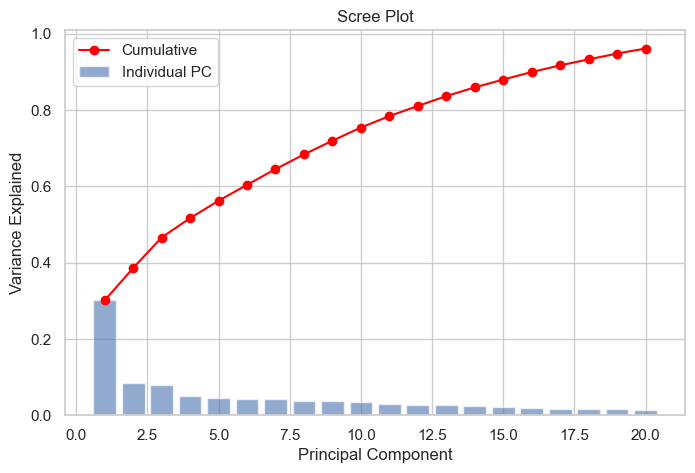

In [19]:
pca = pca_pipeline.named_steps['pca']
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual PC')
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.legend()
plt.show()

## Implementation of a classifcation model

## Cross-Validation Analysis

Before training final models, we'll use cross-validation on the training set to get robust performance estimates and compare different algorithms.

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Store cross-validation results
cv_results = {}

print("Cross-Validation Results (5-Fold):")
print("-" * 60)

for name, model in models.items():
    # Perform cross-validation
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    
    print(f"{name:25s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
    print(f"                          | Fold scores: {scores}")

print("-" * 60)

Cross-Validation Results (5-Fold):
------------------------------------------------------------
Logistic Regression       | Mean: 0.9917 | Std: 0.0102
                          | Fold scores: [0.97916667 0.97916667 1.         1.         1.        ]
Random Forest             | Mean: 0.9833 | Std: 0.0156
                          | Fold scores: [0.97916667 0.95833333 0.97916667 1.         1.        ]
Random Forest             | Mean: 0.9833 | Std: 0.0156
                          | Fold scores: [0.97916667 0.95833333 0.97916667 1.         1.        ]
Gradient Boosting         | Mean: 0.9833 | Std: 0.0156
                          | Fold scores: [1.         0.95833333 0.97916667 0.97916667 1.        ]
SVM                       | Mean: 0.9917 | Std: 0.0102
                          | Fold scores: [0.97916667 1.         0.97916667 1.         1.        ]
Naive Bayes               | Mean: 0.9833 | Std: 0.0156
                          | Fold scores: [0.95833333 1.         0.97916667 0.9791666

C:\Users\RickReyJim\AppData\Local\Temp\ipykernel_20324\1523962113.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


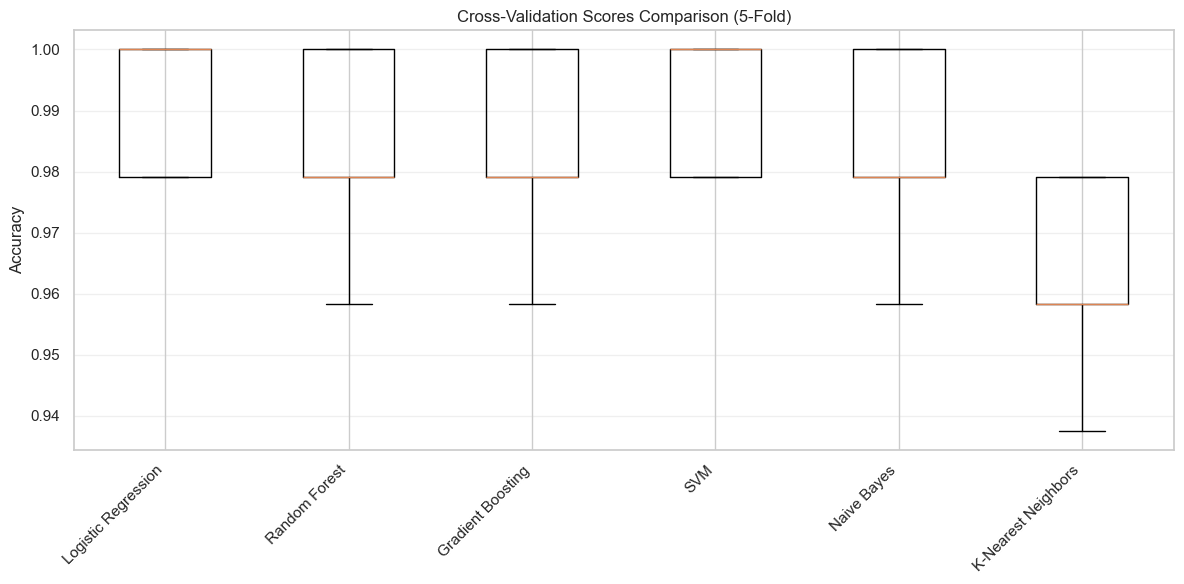

In [21]:
# Visualize cross-validation results
plt.figure(figsize=(12, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores Comparison (5-Fold)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Model Training and Validation

Now we'll train all models on the training set and evaluate them on the validation set.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train all models and evaluate on validation set
val_results = {}

print("Validation Set Results:")
print("-" * 80)
print(f"{'Model':<25s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1-Score':<12s}")
print("-" * 80)

for name, model in models.items():
    # Train on training set
    model.fit(X_train_processed, y_train)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_processed)
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    
    val_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'model': model
    }
    
    print(f"{name:<25s} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("-" * 80)

# Find best model based on F1-score
best_model_name = max(val_results, key=lambda x: val_results[x]['f1_score'])
print(f"\nBest model based on validation F1-score: {best_model_name}")

Validation Set Results:
--------------------------------------------------------------------------------
Model                     Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression       1.0000       1.0000       1.0000       1.0000      
Random Forest             1.0000       1.0000       1.0000       1.0000      
Gradient Boosting         1.0000       1.0000       1.0000       1.0000      
SVM                       1.0000       1.0000       1.0000       1.0000      
Naive Bayes               0.9875       1.0000       0.9800       0.9899      
K-Nearest Neighbors       1.0000       1.0000       1.0000       1.0000      
--------------------------------------------------------------------------------

Best model based on validation F1-score: Logistic Regression
Gradient Boosting         1.0000       1.0000       1.0000       1.0000      
SVM                       1.0000       1.0000  

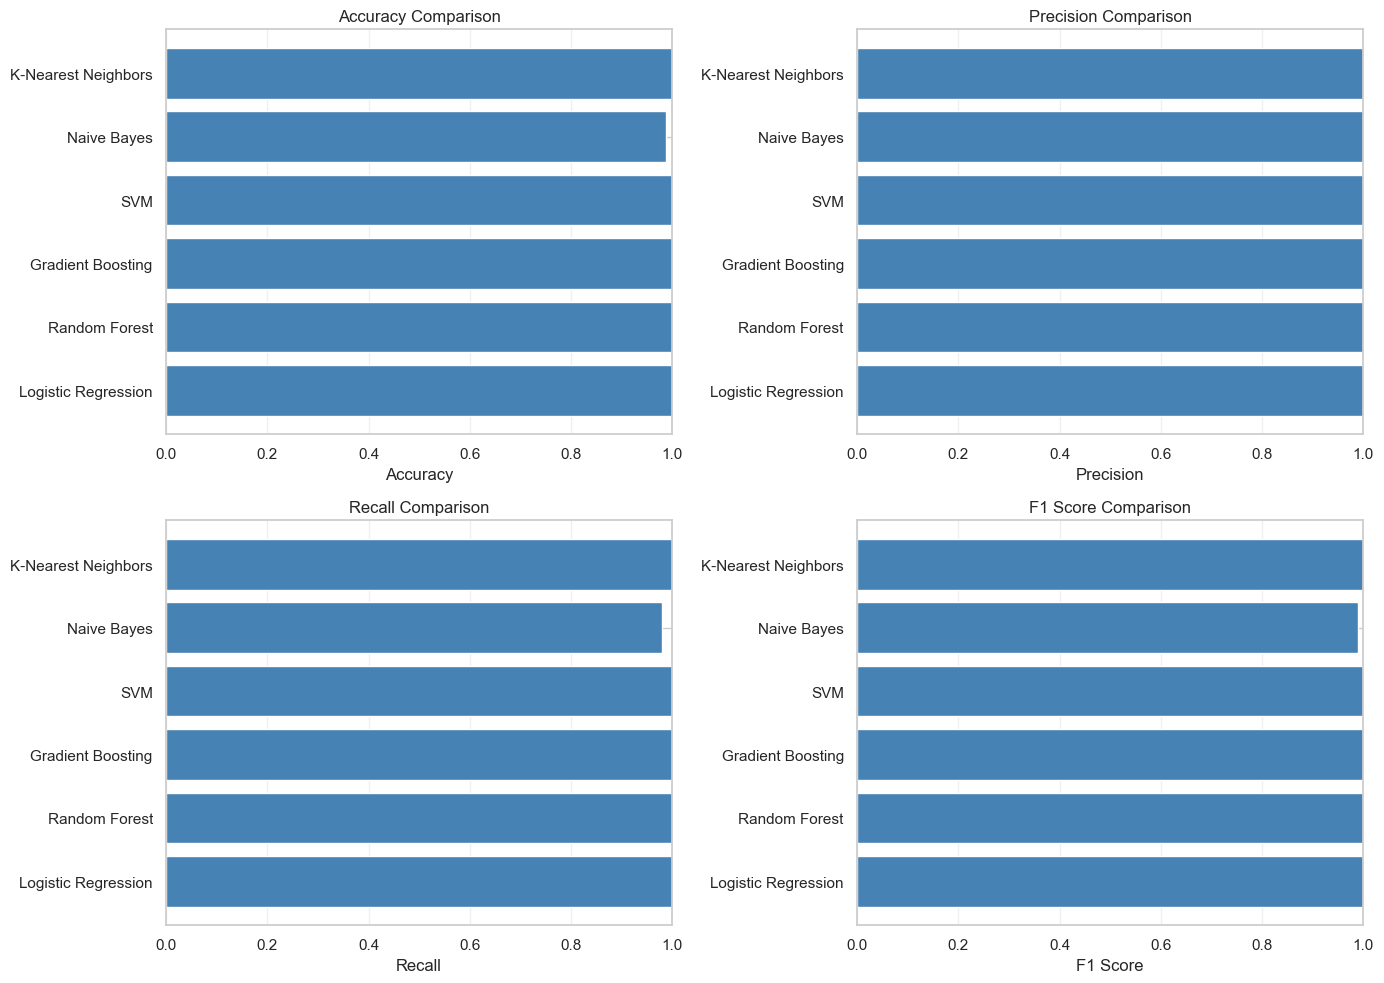

In [23]:
# Visualize validation results comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    values = [val_results[model][metric] for model in val_results.keys()]
    axes[idx].barh(list(val_results.keys()), values, color='steelblue')
    axes[idx].set_xlabel(metric.replace('_', ' ').title())
    axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison')
    axes[idx].set_xlim([0, 1])
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Final Model Evaluation on Test Set

Now we'll evaluate all models on the test set (which has not been used until now) to get unbiased performance estimates.

In [24]:
# Evaluate all models on test set
test_results = {}

print("Test Set Results (Final Evaluation):")
print("-" * 80)
print(f"{'Model':<25s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1-Score':<12s}")
print("-" * 80)

for name, data in val_results.items():
    model = data['model']
    
    # Predict on test set
    y_test_pred = model.predict(X_test_processed)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    test_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'predictions': y_test_pred,
        'model': model
    }
    
    print(f"{name:<25s} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("-" * 80)

# Find best model on test set
best_test_model_name = max(test_results, key=lambda x: test_results[x]['f1_score'])
print(f"\nBest model on test set (F1-score): {best_test_model_name}")

Test Set Results (Final Evaluation):
--------------------------------------------------------------------------------
Model                     Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression       0.9875       1.0000       0.9800       0.9899      
Random Forest             0.9875       1.0000       0.9800       0.9899      
Gradient Boosting         0.9875       1.0000       0.9800       0.9899      
SVM                       0.9875       1.0000       0.9800       0.9899      
Naive Bayes               1.0000       1.0000       1.0000       1.0000      
K-Nearest Neighbors       0.9750       1.0000       0.9600       0.9796      
--------------------------------------------------------------------------------

Best model on test set (F1-score): Naive Bayes


## Detailed Analysis of Best Model

In [25]:
# Get the best model
best_model = test_results[best_test_model_name]['model']
y_pred = test_results[best_test_model_name]['predictions']
y_prob = best_model.predict_proba(X_test_processed)[:, 1]  # probabilities for positive class

print(f"Detailed Analysis for Best Model: {best_test_model_name}")
print("=" * 80)

# -----------------------------
# 1. Classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 2. Confusion matrix
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 3. ROC-AUC score
# -----------------------------
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Detailed Analysis for Best Model: Naive Bayes

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Confusion Matrix:
[[30  0]
 [ 0 50]]

ROC AUC Score: 1.0000


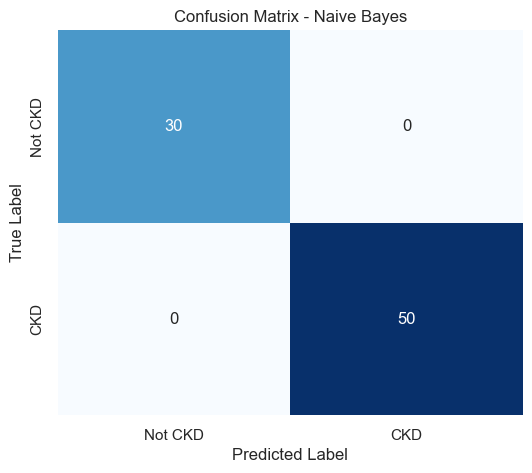

In [26]:
# Compute confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not CKD', 'CKD'],
            yticklabels=['Not CKD', 'CKD'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title(f'Confusion Matrix - {best_test_model_name}')
plt.show()

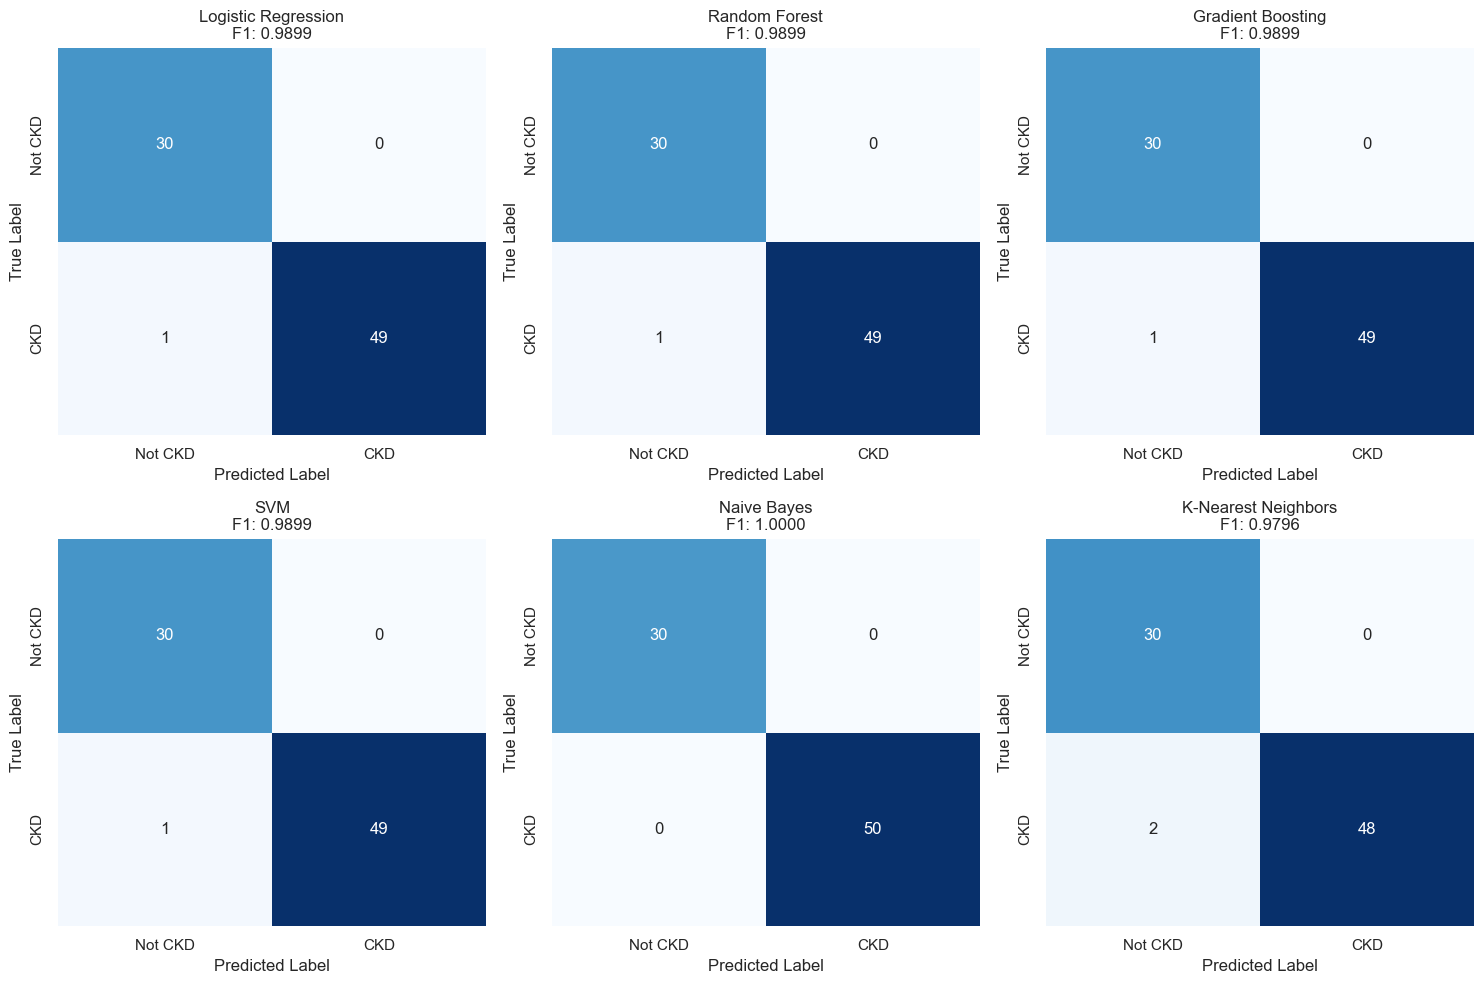

In [27]:
# Compare confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'],
                ax=axes[idx])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_title(f'{name}\nF1: {data["f1_score"]:.4f}')

plt.tight_layout()
plt.show()

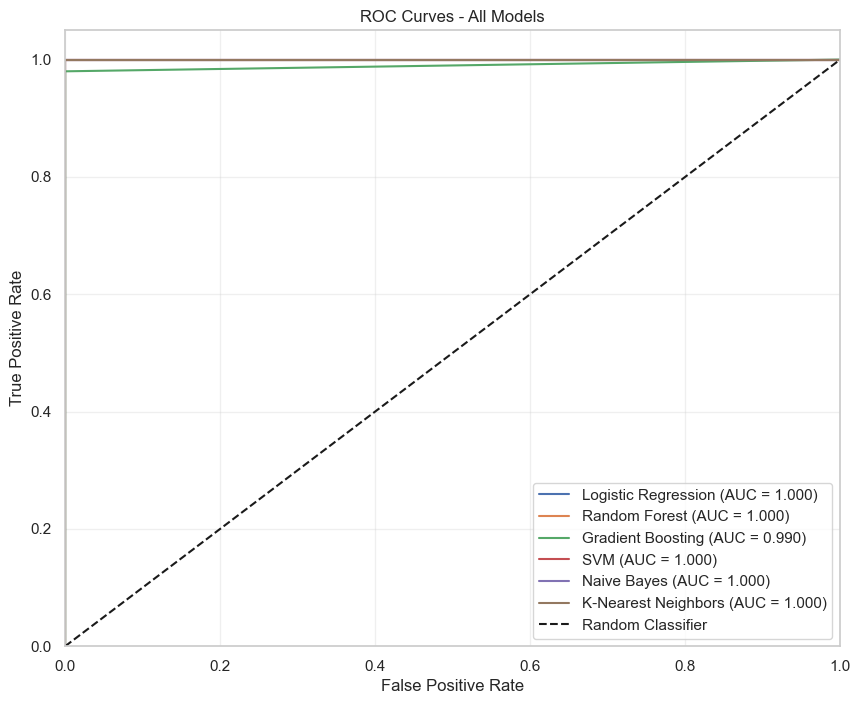

In [28]:
# ROC Curves for all models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, data in test_results.items():
    model = data['model']
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Interesting to add: The below  2D visualization of the data in PCA space (first two PCs), labeled by class. It tells us whether your classes have some visual separation in those components.

With our results, we can see that the overall structure is consistent across splits.

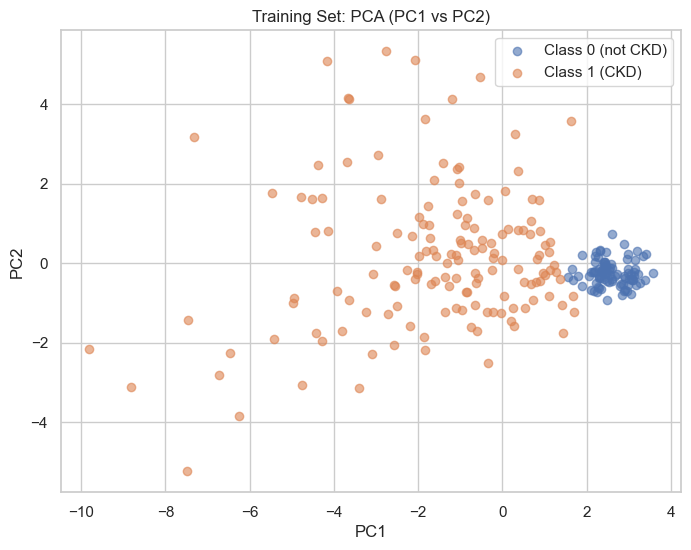

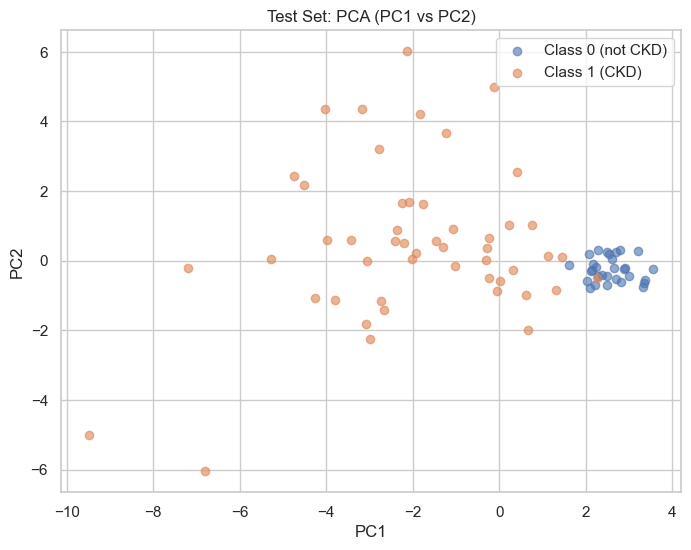

In [29]:
# Get the first two principal components from your PCA pipeline
X_train_2d = X_train_processed[:, :2]
X_test_2d = X_test_processed[:, :2]

# Plot training data
plt.figure(figsize=(8,6))
plt.scatter(X_train_2d[y_train==0, 0], X_train_2d[y_train==0, 1], label='Class 0 (not CKD)', alpha=0.6)
plt.scatter(X_train_2d[y_train==1, 0], X_train_2d[y_train==1, 1], label='Class 1 (CKD)', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Training Set: PCA (PC1 vs PC2)')
plt.legend()
plt.show()

# Plot test data
plt.figure(figsize=(8,6))
plt.scatter(X_test_2d[y_test==0, 0], X_test_2d[y_test==0, 1], label='Class 0 (not CKD)', alpha=0.6)
plt.scatter(X_test_2d[y_test==1, 0], X_test_2d[y_test==1, 1], label='Class 1 (CKD)', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Test Set: PCA (PC1 vs PC2)')
plt.legend()
plt.show()

## Model Deployment - Saving for Production Use

To use these models on new patient data, we need to save:
1. The preprocessing + PCA pipeline
2. The trained models
3. Feature names and order

In [31]:
import joblib
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the PCA pipeline (includes preprocessing)
joblib.dump(pca_pipeline, 'models/pca_pipeline.pkl')

# Save all trained models
for model_name, data in test_results.items():
    model = data['model']
    filename = f"models/{model_name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save the best model separately for quick access
best_model = test_results[best_test_model_name]['model']
joblib.dump(best_model, 'models/best_model.pkl')

# Save feature names (important for new data alignment)
feature_info = {
    'feature_names': X.columns.tolist(),
    'num_cols': num_cols,
    'bool_cols': bool_cols,
    'best_model_name': best_test_model_name
}
with open('models/feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print(f"\n✅ All models saved!")
print(f"✅ Best model: {best_test_model_name}")
print(f"✅ Feature info saved")
print(f"✅ Files saved in: {os.path.abspath('models')}")

Saved: models/logistic_regression_model.pkl
Saved: models/random_forest_model.pkl
Saved: models/gradient_boosting_model.pkl
Saved: models/svm_model.pkl
Saved: models/naive_bayes_model.pkl
Saved: models/k-nearest_neighbors_model.pkl

✅ All models saved!
✅ Best model: Naive Bayes
✅ Feature info saved
✅ Files saved in: c:\GIT\CDK\models


## Making Predictions on New Patient Data

Here's how to load the models and make predictions for a new patient:

In [32]:
# Load the saved models and pipeline
pca_pipeline_loaded = joblib.load('models/pca_pipeline.pkl')
best_model_loaded = joblib.load('models/best_model.pkl')

with open('models/feature_info.pkl', 'rb') as f:
    feature_info = pickle.load(f)

print(f"Loaded best model: {feature_info['best_model_name']}")
print(f"Expected features: {len(feature_info['feature_names'])}")

Loaded best model: Naive Bayes
Expected features: 24


In [33]:
def predict_ckd_risk(patient_data_dict):
    """
    Predict CKD risk for a new patient
    
    Parameters:
    -----------
    patient_data_dict : dict
        Dictionary with patient measurements. Keys should match feature names.
        Example: {
            'age': 48,
            'blood_pressure': 80,
            'specific_gravity': 1.020,
            'albumin': 1,
            'sugar': 0,
            ...
        }
    
    Returns:
    --------
    dict : Prediction results with probability and risk level
    """
    
    # Create DataFrame from patient data
    patient_df = pd.DataFrame([patient_data_dict])
    
    # Ensure all required features are present (fill missing with NaN)
    for feature in feature_info['feature_names']:
        if feature not in patient_df.columns:
            patient_df[feature] = np.nan
    
    # Reorder columns to match training data
    patient_df = patient_df[feature_info['feature_names']]
    
    # Apply PCA pipeline (includes preprocessing)
    patient_processed = pca_pipeline_loaded.transform(patient_df)
    
    # Make prediction
    prediction = best_model_loaded.predict(patient_processed)[0]
    probability = best_model_loaded.predict_proba(patient_processed)[0]
    
    # Interpret results
    result = {
        'has_ckd': bool(prediction),
        'probability_no_ckd': probability[0],
        'probability_ckd': probability[1],
        'risk_level': 'HIGH' if probability[1] > 0.7 else 'MODERATE' if probability[1] > 0.4 else 'LOW',
        'model_used': feature_info['best_model_name']
    }
    
    return result

# Example usage
print("Function created: predict_ckd_risk()")

Function created: predict_ckd_risk()


### Example: Predicting for a New Patient

In [34]:
# Example patient data (you can have partial data - missing values will be imputed)
new_patient = {
    'age': 48,
    'blood_pressure': 80,
    'specific_gravity': 1.020,
    'albumin': 1,
    'sugar': 0,
    'red_blood_cells': 1,  # 1 = normal, 0 = abnormal
    'pus_cell': 1,
    'pus_cell_clumps': 0,  # 0 = not present, 1 = present
    'bacteria': 0,
    'blood_glucose_random': 121,
    'blood_urea': 36,
    'serum_creatinine': 1.2,
    'sodium': 138,
    'potassium': 4.5,
    'haemoglobin': 15.4,
    'packed_cell_volume': 44,
    'white_blood_cell_count': 7800,
    'red_blood_cell_count': 5.2,
    'hypertension': 0,  # 0 = no, 1 = yes
    'diabetes_mellitus': 0,
    'coronary_artery_disease': 0,
    'appetite': 1,  # 1 = good, 0 = poor
    'peda_edema': 0,
    'anemia': 0
}

# Make prediction
result = predict_ckd_risk(new_patient)

# Display results
print("="*60)
print("CKD RISK ASSESSMENT")
print("="*60)
print(f"Patient has CKD: {'YES' if result['has_ckd'] else 'NO'}")
print(f"CKD Probability: {result['probability_ckd']*100:.1f}%")
print(f"Risk Level: {result['risk_level']}")
print(f"Model Used: {result['model_used']}")
print("="*60)

CKD RISK ASSESSMENT
Patient has CKD: NO
CKD Probability: 0.0%
Risk Level: LOW
Model Used: Naive Bayes


### Testing with Multiple Patients from Test Set

In [35]:
# Verify the function works with actual test data
print("Testing prediction function with 5 patients from test set:\n")

for i in range(5):
    # Get patient data
    patient_dict = X_test.iloc[i].to_dict()
    actual_label = y_test.iloc[i]
    
    # Make prediction
    pred_result = predict_ckd_risk(patient_dict)
    
    print(f"Patient {i+1}:")
    print(f"  Actual: {'CKD' if actual_label == 1 else 'No CKD'}")
    print(f"  Predicted: {'CKD' if pred_result['has_ckd'] else 'No CKD'}")
    print(f"  CKD Probability: {pred_result['probability_ckd']*100:.1f}%")
    print(f"  Risk Level: {pred_result['risk_level']}")
    print(f"  ✓ Correct" if (pred_result['has_ckd'] == actual_label) else "  ✗ Incorrect")
    print()

Testing prediction function with 5 patients from test set:

Patient 1:
  Actual: No CKD
  Predicted: No CKD
  CKD Probability: 0.0%
  Risk Level: LOW
  ✓ Correct

Patient 2:
  Actual: CKD
  Predicted: CKD
  CKD Probability: 100.0%
  Risk Level: HIGH
  ✓ Correct

Patient 3:
  Actual: CKD
  Predicted: CKD
  CKD Probability: 100.0%
  Risk Level: HIGH
  ✓ Correct

Patient 4:
  Actual: No CKD
  Predicted: No CKD
  CKD Probability: 0.0%
  Risk Level: LOW
  ✓ Correct

Patient 5:
  Actual: CKD
  Predicted: CKD
  CKD Probability: 100.0%
  Risk Level: HIGH
  ✓ Correct



## Creating a Simple API Endpoint (Optional)

For production deployment, you can create a Flask/FastAPI endpoint:

In [ ]:
# Save this as: predict_api.py
api_code = '''
from flask import Flask, request, jsonify
import joblib
import pickle
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load models on startup
pca_pipeline = joblib.load('models/pca_pipeline.pkl')
best_model = joblib.load('models/best_model.pkl')
with open('models/feature_info.pkl', 'rb') as f:
    feature_info = pickle.load(f)

@app.route('/predict', methods=['POST'])
def predict():
    """API endpoint to predict CKD risk"""
    try:
        # Get patient data from request
        patient_data = request.json
        
        # Create DataFrame
        patient_df = pd.DataFrame([patient_data])
        
        # Ensure all features present
        for feature in feature_info['feature_names']:
            if feature not in patient_df.columns:
                patient_df[feature] = np.nan
        
        # Reorder columns
        patient_df = patient_df[feature_info['feature_names']]
        
        # Transform and predict
        patient_processed = pca_pipeline.transform(patient_df)
        prediction = best_model.predict(patient_processed)[0]
        probability = best_model.predict_proba(patient_processed)[0]
        
        # Return results
        return jsonify({
            'has_ckd': bool(prediction),
            'probability_ckd': float(probability[1]),
            'risk_level': 'HIGH' if probability[1] > 0.7 else 'MODERATE' if probability[1] > 0.4 else 'LOW',
            'model': feature_info['best_model_name']
        })
    
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy', 'model_loaded': True})

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)
'''

# Save API code to file
with open('predict_api.py', 'w') as f:
    f.write(api_code)

print("✅ API code saved to: predict_api.py")
print("\nTo run the API:")
print("  1. Install Flask: pip install flask")
print("  2. Run: python predict_api.py")
print("  3. Test: curl -X POST http://localhost:5000/predict -H 'Content-Type: application/json' -d '{...}'")
